In [50]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Carreguem
df = pd.read_csv('../data/processed/df_features.csv')
y  = pd.read_csv('../data/processed/y.csv').squeeze()

# Separem train i test
train = df.iloc[:len(y)]
test  = df.iloc[len(y):]

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print(f"Target: {y.shape}")

Train: (1458, 249)
Test:  (1459, 249)
Target: (1458,)


In [51]:
# Escalem — Ridge necessita features a la mateixa escala
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
test_scaled  = scaler.transform(test)

# Cross-validation amb 5 folds
ridge = Ridge(alpha=10)
scores = cross_val_score(ridge, train_scaled, y, 
                         cv=5, scoring='neg_root_mean_squared_error')

print(f"Ridge CV log-RMSE: {-scores.mean():.4f} ± {scores.std():.4f}")

Ridge CV log-RMSE: 0.1217 ± 0.0068


In [52]:
xgb_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, 
                               random_state=42)
scores_xgb = cross_val_score(xgb_model, train, y,
                              cv=5, scoring='neg_root_mean_squared_error')

print(f"XGBoost CV log-RMSE: {-scores_xgb.mean():.4f} ± {scores_xgb.std():.4f}")

XGBoost CV log-RMSE: 0.1233 ± 0.0059


In [53]:
from sklearn.model_selection import GridSearchCV

alphas = [0.1, 1, 5, 10, 50, 100, 300, 500]
ridge_grid = GridSearchCV(Ridge(), {'alpha': alphas}, 
                          cv=5, scoring='neg_root_mean_squared_error')
ridge_grid.fit(train_scaled, y)

print(f"Ridge millor alpha: {ridge_grid.best_params_}")
print(f"Ridge millor CV log-RMSE: {-ridge_grid.best_score_:.4f}")

Ridge millor alpha: {'alpha': 300}
Ridge millor CV log-RMSE: 0.1162


In [54]:
xgb_tuned = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

scores_xgb_tuned = cross_val_score(xgb_tuned, train, y,
                                    cv=5, scoring='neg_root_mean_squared_error')

print(f"XGBoost tuned CV log-RMSE: {-scores_xgb_tuned.mean():.4f} ± {scores_xgb_tuned.std():.4f}")

XGBoost tuned CV log-RMSE: 0.1136 ± 0.0058


In [55]:
# Ridge — entrenem amb totes les dades de train
ridge_final = Ridge(alpha=300)
ridge_final.fit(train_scaled, y)
pred_ridge_train = ridge_final.predict(train_scaled)
pred_ridge_test  = ridge_final.predict(test_scaled)

# XGBoost — entrenem amb totes les dades de train
xgb_final = xgb.XGBRegressor(
    n_estimators=2000, learning_rate=0.01,
    max_depth=4, min_child_weight=2,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42
)
xgb_final.fit(train, y)
pred_xgb_train = xgb_final.predict(train)
pred_xgb_test  = xgb_final.predict(test)

print("Models entrenats!")

Models entrenats!


In [56]:
# Blend — mitjana ponderada de les dues prediccions
# Donem més pes a XGBoost perquè té millor CV score
blend_train = 0.4 * pred_ridge_train + 0.6 * pred_xgb_train
blend_test  = 0.4 * pred_ridge_test  + 0.6 * pred_xgb_test

# Avaluem el blend al train
from sklearn.metrics import mean_squared_error
rmse_blend = np.sqrt(mean_squared_error(y, blend_train))
print(f"Blend log-RMSE train: {rmse_blend:.4f}")

# Comparem els tres

print(f"Blend train: {rmse_blend:.4f}")

Blend log-RMSE train: 0.0611
Blend train: 0.0611


In [57]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
blend_scores = []

for train_idx, val_idx in kf.split(train):
    # Split
    X_tr, X_val = train.iloc[train_idx], train.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Ridge
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)
    ridge_final.fit(X_tr_sc, y_tr)
    p_ridge = ridge_final.predict(X_val_sc)
    
    # XGBoost
    xgb_final.fit(X_tr, y_tr)
    p_xgb = xgb_final.predict(X_val)
    
    # Blend
    p_blend = 0.4 * p_ridge + 0.6 * p_xgb
    score = np.sqrt(mean_squared_error(y_val, p_blend))
    blend_scores.append(score)


print(f"\nResum:")
print(f"Ridge    CV: {-ridge_grid.best_score_:.4f}")
print(f"XGBoost  CV: {-scores_xgb_tuned.mean():.4f} ± {scores_xgb_tuned.std():.4f}")
print(f"Blend    CV: {np.mean(blend_scores):.4f} ± {np.std(blend_scores):.4f}")


Resum:
Ridge    CV: 0.1162
XGBoost  CV: 0.1136 ± 0.0058
Blend    CV: 0.1102 ± 0.0070


In [58]:
df = df.copy()
df.to_csv('../data/processed/df_features.csv', index=False)
y.to_csv('../data/processed/y.csv', index=False)
print(f"Dataset guardat! Shape: {df.shape}")

Dataset guardat! Shape: (2917, 249)


In [59]:
print(f"y shape: {y.shape}")
print(f"y valors: {y.head()}")

y shape: (1458,)
y valors: 0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice, dtype: float64


In [60]:
print(f"df shape: {df.shape}")
print(f"y shape: {len(y)}")
print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")

df shape: (2917, 249)
y shape: 1458
train shape: (1458, 249)
test shape: (1459, 249)


In [61]:
# Desfer el log1p per obtenir preus reals
submission = pd.read_csv('../data/raw/sample_submission.csv')
submission['SalePrice'] = np.expm1(blend_test)

submission.to_csv('../submissions/submission_02_blend.csv', index=False)
print("Submission guardada!")
print(submission.head())

Submission guardada!
     Id      SalePrice
0  1461  120692.158253
1  1462  160959.550258
2  1463  179762.265795
3  1464  196136.437612
4  1465  188439.535858


In [62]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

scores_lgb = cross_val_score(lgb_model, train, y,
                              cv=5, scoring='neg_root_mean_squared_error')

print(f"LightGBM CV log-RMSE: {-scores_lgb.mean():.4f} ± {scores_lgb.std():.4f}")

LightGBM CV log-RMSE: 0.1206 ± 0.0043


In [63]:
lgb_fast = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbose=-1
)

scores_lgb_fast = cross_val_score(lgb_fast, train, y,
                                   cv=5, scoring='neg_root_mean_squared_error')
print(f"LightGBM fast CV log-RMSE: {-scores_lgb_fast.mean():.4f} ± {scores_lgb_fast.std():.4f}")

LightGBM fast CV log-RMSE: 0.1220 ± 0.0041


In [64]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
blend_scores = []

for train_idx, val_idx in kf.split(train):
    X_tr, X_val = train.iloc[train_idx], train.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Ridge
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)
    ridge_final.fit(X_tr_sc, y_tr)
    p_ridge = ridge_final.predict(X_val_sc)
    
    # XGBoost
    xgb_final.fit(X_tr, y_tr)
    p_xgb = xgb_final.predict(X_val)
    
    # LightGBM
    lgb_fast.fit(X_tr, y_tr)
    p_lgb = lgb_fast.predict(X_val)
    
    # Blend 3 models
    p_blend = 0.3 * p_ridge + 0.5 * p_xgb + 0.2 * p_lgb
    score = np.sqrt(mean_squared_error(y_val, p_blend))
    blend_scores.append(score)

print(f"Blend 3 models CV log-RMSE: {np.mean(blend_scores):.4f} ± {np.std(blend_scores):.4f}")

Blend 3 models CV log-RMSE: 0.1113 ± 0.0074


In [65]:
# Quines cases prediu pitjor?
ridge_final.fit(train_scaled, y)
pred_train = ridge_final.predict(train_scaled)
residuals = y - pred_train

# Cases amb error més gran
error_df = pd.DataFrame({
    'real': np.expm1(y),
    'predit': np.expm1(pred_train),
    'error': np.abs(residuals)
}).sort_values('error', ascending=False)

print(error_df.head(10))

          real         predit     error
631    82500.0  164341.764324  0.689144
462    62383.0  115657.924643  0.617337
1322  147000.0  265722.928882  0.592019
967    37900.0   62657.727766  0.502725
30     40000.0   64763.052776  0.481846
1430   64500.0  103392.349727  0.471860
969   135000.0   84950.170746  0.463206
495    34900.0   54223.807655  0.440623
709    52000.0   77660.943332  0.401102
532    39300.0   57567.413330  0.381724


In [66]:
# Analitzem les cases amb més error
error_idx = error_df.head(18).index

train_original = pd.read_csv('../data/raw/train.csv')
train_original.iloc[error_idx][['SalePrice', 'Neighborhood', 'SaleCondition', 
                                 'OverallQual', 'GrLivArea', 'YearBuilt']]

,SalePrice,Neighborhood,SaleCondition,OverallQual,GrLivArea,YearBuilt
631,209500,NridgHt,Normal,8,1554,2006
462,62383,Sawyer,Normal,5,864,1965
1322,190000,NoRidge,Normal,7,1923,1992
967,135000,NAmes,Normal,5,1098,1955
30,40000,IDOTRR,Normal,4,1317,1920
1430,192140,Gilbert,Normal,5,1838,2005
969,140000,NAmes,Normal,6,1095,1958
495,34900,IDOTRR,Abnorml,4,720,1920
709,109900,Sawyer,Abnorml,5,904,1966
532,107500,NAmes,Normal,5,827,1955


In [67]:
print(f"Cases mal avaluades (error > 0.3): {(np.abs(residuals) > 0.3).sum()}")
print(f"Total cases train: {len(train)}")
print(f"Percentatge: {(np.abs(residuals) > 0.3).mean()*100:.1f}%")

Cases mal avaluades (error > 0.3): 18
Total cases train: 1458
Percentatge: 1.2%


In [68]:
# Llindar 15% en escala log
llindar = np.log1p(1.15) - np.log1p(1)
print(f"Llindar log equivalent al 15%: {llindar:.3f}")

print(f"\nError > 15%: {(np.abs(residuals) > llindar).sum()} cases ({(np.abs(residuals) > llindar).mean()*100:.1f}%)")

Llindar log equivalent al 15%: 0.072

Error > 15%: 527 cases (36.1%)


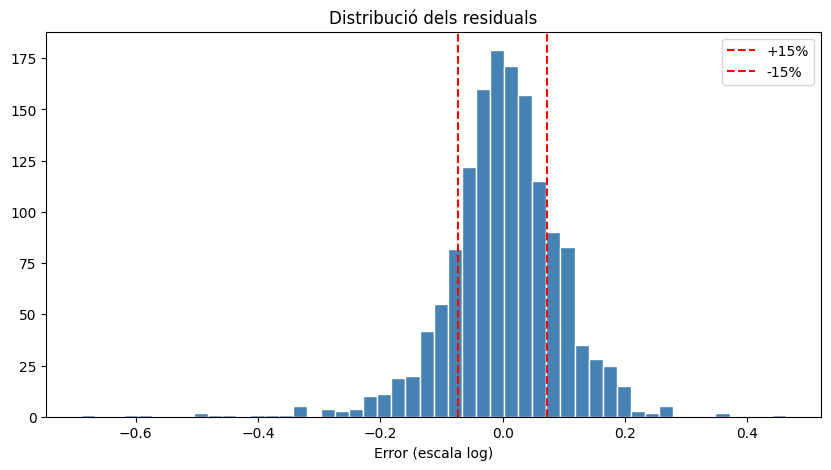

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=llindar, color='red', linestyle='--', label='+15%')
plt.axvline(x=-llindar, color='red', linestyle='--', label='-15%')
plt.title('Distribució dels residuals')
plt.xlabel('Error (escala log)')
plt.legend()
plt.show()

In [70]:
print(f"test shape: {test.shape}")
print(f"blend_test shape: {len(blend_test)}")

test shape: (1459, 249)
blend_test shape: 1459


In [72]:
import matplotlib.pyplot as plt

# Feature importance de XGBoost
xgb_final.fit(train, y)
importance = pd.Series(xgb_final.feature_importances_, index=train.columns)
importance = importance.sort_values(ascending=False)

# Top 20 i bottom 20
print("\nBOTTOM 20 — candidates a eliminar:")
print(importance.tail(20))


BOTTOM 20 — candidates a eliminar:
Heating_GasW           0.0
Heating_Floor          0.0
Foundation_Stone       0.0
Foundation_Slab        0.0
Exterior2nd_Stone      0.0
GarageType_None        0.0
Exterior2nd_Other      0.0
Exterior2nd_CBlock     0.0
SaleType_CWD           0.0
Exterior2nd_AsphShn    0.0
Exterior1st_Stone      0.0
Exterior1st_ImStucc    0.0
Fence_MnWw             0.0
Exterior1st_CBlock     0.0
MiscFeature_Gar2       0.0
Exterior1st_BrkComm    0.0
MiscFeature_Othr       0.0
Exterior1st_AsphShn    0.0
MiscFeature_TenC       0.0
LotShape_IR3           0.0
dtype: float32


In [73]:
zero_importance = importance[importance == 0]
print(f"Features amb importància 0: {len(zero_importance)}")
print(f"Total features: {len(importance)}")

Features amb importància 0: 50
Total features: 249


In [74]:
# Eliminem features amb importància 0
cols_to_drop = zero_importance.index.tolist()
train_reduced = train.drop(cols_to_drop, axis=1)
test_reduced  = test.drop(cols_to_drop, axis=1)

print(f"Features abans: {train.shape[1]}")
print(f"Features després: {train_reduced.shape[1]}")

# CV amb XGBoost reduït
scores_reduced = cross_val_score(xgb_final, train_reduced, y,
                                  cv=5, scoring='neg_root_mean_squared_error')
print(f"XGBoost reduït CV: {-scores_reduced.mean():.4f} ± {scores_reduced.std():.4f}")

Features abans: 249
Features després: 199
XGBoost reduït CV: 0.1141 ± 0.0055


In [75]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
blend_scores = []

for train_idx, val_idx in kf.split(train_reduced):
    X_tr, X_val = train_reduced.iloc[train_idx], train_reduced.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)
    
    ridge_final.fit(X_tr_sc, y_tr)
    p_ridge = ridge_final.predict(X_val_sc)
    
    xgb_final.fit(X_tr, y_tr)
    p_xgb = xgb_final.predict(X_val)
    
    p_blend = 0.4 * p_ridge + 0.6 * p_xgb
    score = np.sqrt(mean_squared_error(y_val, p_blend))
    blend_scores.append(score)

print(f"Blend reduït CV: {np.mean(blend_scores):.4f} ± {np.std(blend_scores):.4f}")

Blend reduït CV: 0.1093 ± 0.0070


In [76]:
# Entrenem amb totes les dades reduïdes
ridge_final.fit(scaler.fit_transform(train_reduced), y)
xgb_final.fit(train_reduced, y)

pred_ridge = ridge_final.predict(scaler.transform(test_reduced))
pred_xgb   = xgb_final.predict(test_reduced)

blend_test = 0.4 * pred_ridge + 0.6 * pred_xgb

submission = pd.read_csv('../data/raw/sample_submission.csv')
submission['SalePrice'] = np.expm1(blend_test)
submission.to_csv('../submissions/submission_02_blend_reduced.csv', index=False)
print("Submission guardada!")

Submission guardada!


In [77]:
low_importance = importance[importance < 0.001]
print(f"Features amb importància < 0.001: {len(low_importance)}")
print(low_importance.sort_values())

Features amb importància < 0.001: 139
LotShape_IR3            0.000000
Utilities_NoSeWa        0.000000
LotConfig_FR3           0.000000
Neighborhood_Blueste    0.000000
Neighborhood_BrDale     0.000000
                          ...   
Neighborhood_Somerst    0.000965
Neighborhood_Sawyer     0.000967
Neighborhood_Mitchel    0.000969
Neighborhood_SWISU      0.000972
Neighborhood_Blmngtn    0.000989
Length: 139, dtype: float32


In [78]:
for llindar in [0.001, 0.002, 0.005, 0.01]:
    n = (importance < llindar).sum()
    print(f"< {llindar}: {n} features a eliminar → {249-n} restants")

< 0.001: 139 features a eliminar → 110 restants
< 0.002: 187 features a eliminar → 62 restants
< 0.005: 217 features a eliminar → 32 restants
< 0.01: 230 features a eliminar → 19 restants


In [79]:
for llindar in [0.001, 0.002, 0.005, 0.01]:
    cols_keep = importance[importance >= llindar].index.tolist()
    X_red = train[cols_keep]
    
    scores = cross_val_score(xgb_final, X_red, y,
                             cv=5, scoring='neg_root_mean_squared_error')
    print(f"Llindar {llindar} ({len(cols_keep)} features): CV {-scores.mean():.4f} ± {scores.std():.4f}")

Llindar 0.001 (110 features): CV 0.1125 ± 0.0063
Llindar 0.002 (62 features): CV 0.1142 ± 0.0058
Llindar 0.005 (32 features): CV 0.1206 ± 0.0066
Llindar 0.01 (19 features): CV 0.1370 ± 0.0066


In [80]:
cols_keep = importance[importance >= 0.001].index.tolist()
train_reduced2 = train[cols_keep]
test_reduced2  = test[cols_keep]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
blend_scores = []

for train_idx, val_idx in kf.split(train_reduced2):
    X_tr, X_val = train_reduced2.iloc[train_idx], train_reduced2.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)
    
    ridge_final.fit(X_tr_sc, y_tr)
    p_ridge = ridge_final.predict(X_val_sc)
    
    xgb_final.fit(X_tr, y_tr)
    p_xgb = xgb_final.predict(X_val)
    
    p_blend = 0.4 * p_ridge + 0.6 * p_xgb
    score = np.sqrt(mean_squared_error(y_val, p_blend))
    blend_scores.append(score)

print(f"Blend 110 features CV: {np.mean(blend_scores):.4f} ± {np.std(blend_scores):.4f}")

Blend 110 features CV: 0.1090 ± 0.0071


In [81]:
ridge_final.fit(scaler.fit_transform(train_reduced2), y)
xgb_final.fit(train_reduced2, y)

pred_ridge = ridge_final.predict(scaler.transform(test_reduced2))
pred_xgb   = xgb_final.predict(test_reduced2)

blend_test = 0.4 * pred_ridge + 0.6 * pred_xgb

submission = pd.read_csv('../data/raw/sample_submission.csv')
submission['SalePrice'] = np.expm1(blend_test)
submission.to_csv('../submissions/submission_03_110features.csv', index=False)
print("Submission guardada!")

Submission guardada!


In [82]:
from sklearn.model_selection import GridSearchCV

xgb_reg = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

params = {
    'reg_alpha':  [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 2, 5, 10],
}

grid = GridSearchCV(xgb_reg, params, cv=5, 
                    scoring='neg_root_mean_squared_error')
grid.fit(train_reduced, y)

print(f"Millors params: {grid.best_params_}")
print(f"Millor CV: {-grid.best_score_:.4f}")

Millors params: {'reg_alpha': 0, 'reg_lambda': 2}
Millor CV: 0.1152
